## Latent Z variation analysis


### Imports


In [1]:
%matplotlib widget

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd
import torch

from pathlib import Path

sys.path.insert(0, os.path.join(os.path.abspath(os.pardir), "src"))
from molearn.data import PDBData
from molearn.models.CNN_autoencoder import AutoEncoder
from molearn.analysis import MolearnAnalysis
from molearn.analysis.plot import *

RANDOM_STATE = 42


atoms = ["N", "CA", "C", "O", 'CB']

mean = json.load(open("../data/data_statistics_full.json"))["mean"]
std = json.load(open("../data/data_statistics_full.json"))["std"]

data_closed = PDBData(
    filename=["../data/full_murd_closed.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_closed.prepare_dataset(mean=mean, std=std)

data_open = PDBData(
    filename=["../data/full_murd_open.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_open.prepare_dataset(mean=mean, std=std)

data_test = PDBData(
    filename=["../data/full_murd_closed_open_1.pdb"],
    atoms=atoms,
    fix_terminal=True,
)
_ = data_test.prepare_dataset(mean=mean, std=std)



Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([2000, 2145, 3])
Using pre-computed mean: 17.09642555407783, std: 23.559262743825876
Dataset shape: torch.Size([200, 2145, 3])


### Loading models / results

In [12]:
log_dfs = {}
min_valid_losses = {}
min_valid_mse_losses = {}
models = {}
MAs = {}

base_path = r"../results/28-nov-2025-latent-z-n"

device = 'cuda' if torch.cuda.is_available() else 'cpu'

for n in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:

    log_dfs[n] = pd.read_csv(Path(f"{base_path}/{n}/log.dat"))
    best_epoch = log_dfs[n]['valid_loss'].idxmin()
    min_valid_losses[n] = min(log_dfs[n].valid_loss)
    min_valid_mse_losses[n] = min(log_dfs[n].valid_mse_loss)

    checkpoint_path = Path(f"{base_path}/{n}/checkpoint_converged.ckpt")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    model = AutoEncoder(latent_z=n)
    model.load_state_dict(checkpoint['model_state_dict'])

    models[n] = model

    MA = MolearnAnalysis() 
    MA.batch_size = 16
    MA.processes = 4

    MA.set_dataset(data=data_open, key="train_open")
    MA.set_dataset(data=data_closed, key="train_closed")
    MA.set_dataset(data=data_test, key="test_trans")

    MA.set_network(models[n])

    MAs[n] = MA

### Model Architecture and Shapes

In [ ]:
from molearn.models.CNN_autoencoder import ToND, FromND
from torch import nn


def print_encoder_shapes(model, n_atoms):
    """Print the shape at each stage of the encoder"""
    # Create dummy input: (batch=1, atoms=n_atoms, coords=3)
    x = torch.randn(1, n_atoms, 3)
    
    # Permute to (batch, 3, atoms) as encoder expects
    x = x.permute(0, 2, 1)
    print(f"Input shape: {x.shape}")
    
    for i, m in enumerate(model.encoder):
        if isinstance(m, ToND):
            # ToND expects unsqueezed input
            x_unsqueezed = x.unsqueeze(-1)
            print(f"  After unsqueeze(-1): {x_unsqueezed.shape}")
            x = m(x_unsqueezed)
        else:
            x = m(x)
        
        # Print shape after certain layer types
        if isinstance(m, (nn.Conv1d, nn.ConvTranspose1d, ToND, FromND)):
            print(f"Layer {i} ({m.__class__.__name__}): {x.shape}")
    
    print(f"\nFinal latent shape: {x.shape}")
    return x



latent_z = 1

print("=" * 60)
print(f"ENCODER FORWARD PASS - latent_z={latent_z}")
print("=" * 60)
z = print_encoder_shapes(models[latent_z], n_atoms=data_open.dataset.shape[1])
print(data_open.dataset.shape)

ENCODER FORWARD PASS - latent_z=1
Input shape: torch.Size([1, 3, 2145])
Layer 0 (Conv1d): torch.Size([1, 32, 1072])
Layer 3 (Conv1d): torch.Size([1, 48, 536])
Layer 6 (Conv1d): torch.Size([1, 72, 268])
Layer 9 (Conv1d): torch.Size([1, 108, 134])
Layer 12 (Conv1d): torch.Size([1, 162, 67])
Layer 15 (Conv1d): torch.Size([1, 1, 33])
  After unsqueeze(-1): torch.Size([1, 1, 33, 1])
Layer 16 (ToND): torch.Size([1, 2])

Final latent shape: torch.Size([1, 2])
torch.Size([2000, 2145, 3])


### MSE & Loss Plots

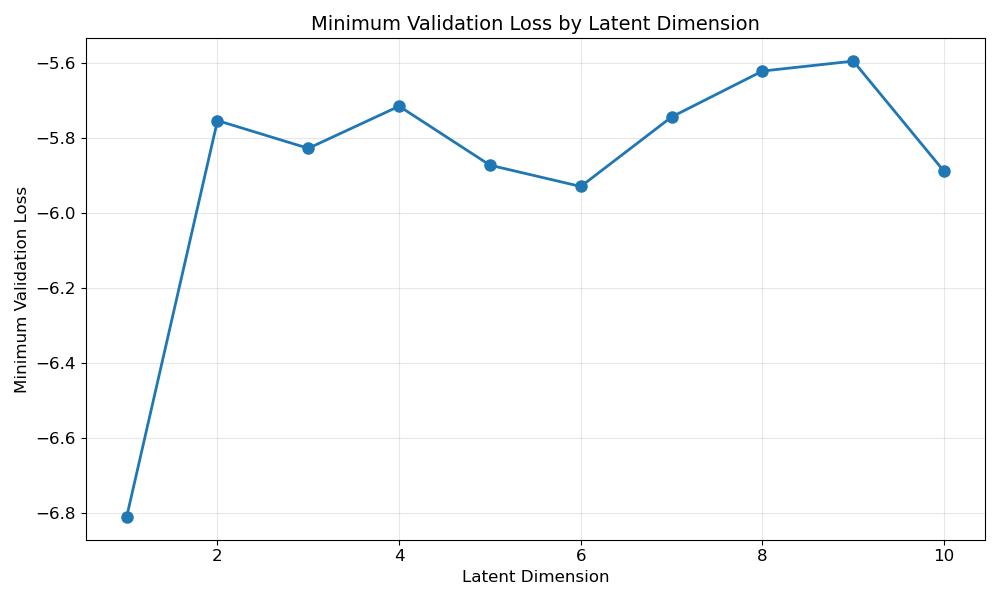

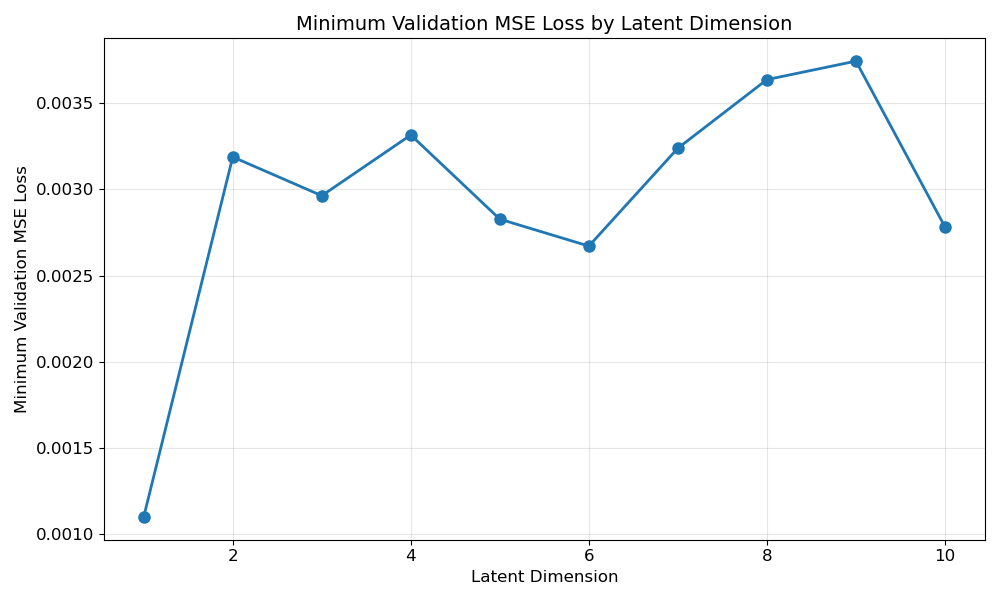

In [13]:
# Plot line graph of minimum validation losses
plt.figure(figsize=(10, 6))
plt.plot(list(min_valid_losses.keys()), list(min_valid_losses.values()), marker='o', linewidth=2, markersize=8)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Minimum Validation Loss', fontsize=12)
plt.title('Minimum Validation Loss by Latent Dimension', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot line graph of minimum validation MSE_losses
plt.figure(figsize=(10, 6))
plt.plot(list(min_valid_mse_losses.keys()), list(min_valid_mse_losses.values()), marker='o', linewidth=2, markersize=8)
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Minimum Validation MSE Loss', fontsize=12)
plt.title('Minimum Validation MSE Loss by Latent Dimension', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Basic Analysis Plots

#### RMSD Hist plot

encoding train_open: 0it [00:00, ?it/s]

encoding train_open: 125it [00:00, 250.62it/s]
Decoding train_open: 125it [00:01, 119.64it/s]
encoding train_closed: 125it [00:00, 293.25it/s]
Decoding train_closed: 125it [00:01, 114.71it/s]
encoding test_trans: 13it [00:00, 333.23it/s]
Decoding test_trans: 13it [00:00, 157.94it/s]


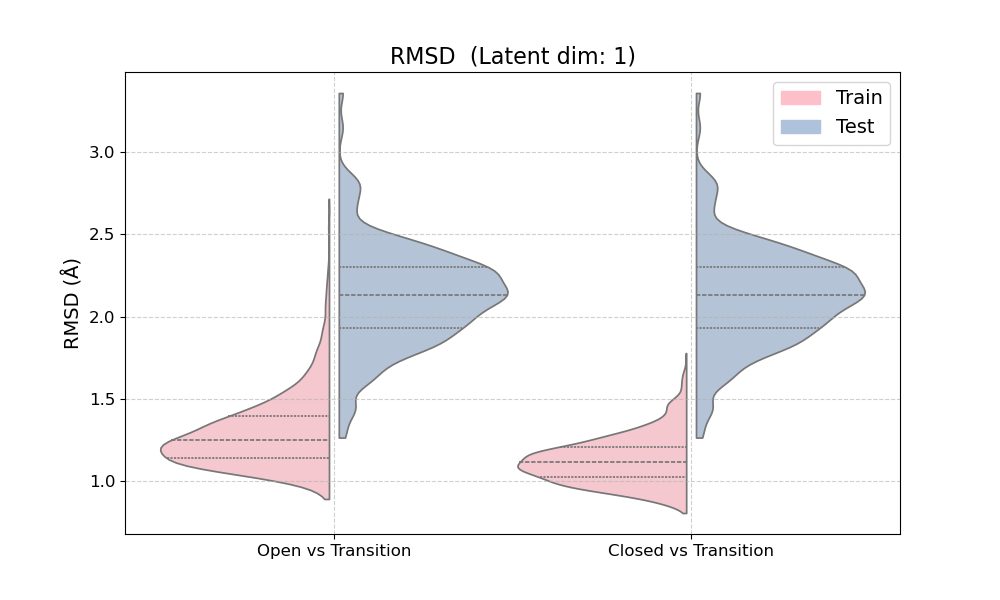

encoding train_open: 125it [00:00, 219.54it/s]
Decoding train_open: 125it [00:01, 102.05it/s]
encoding train_closed: 125it [00:00, 261.01it/s]
Decoding train_closed: 125it [00:01, 96.36it/s]
encoding test_trans: 13it [00:00, 310.71it/s]
Decoding test_trans: 13it [00:00, 137.82it/s]


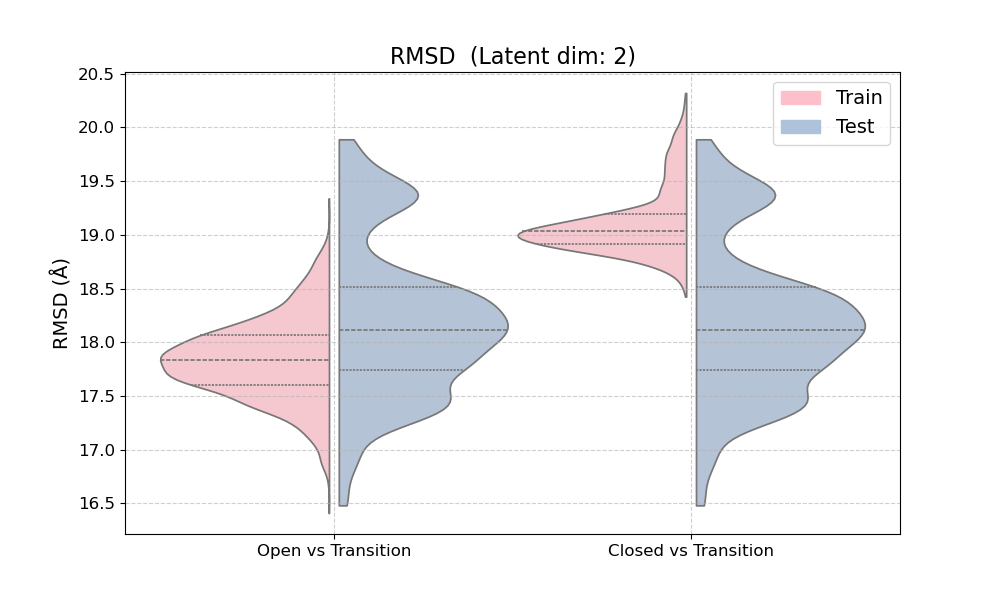

encoding train_open: 125it [00:00, 294.55it/s]
Decoding train_open: 125it [00:01, 107.78it/s]
encoding train_closed: 125it [00:00, 291.32it/s]
Decoding train_closed: 125it [00:01, 120.57it/s]
encoding test_trans: 13it [00:00, 337.80it/s]
Decoding test_trans: 13it [00:00, 116.95it/s]


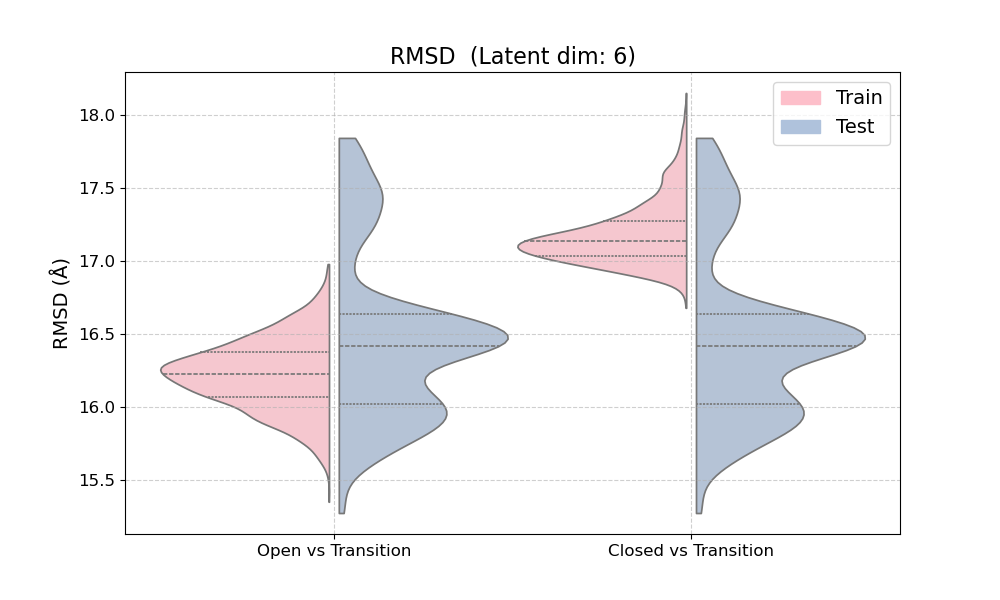

In [14]:
from molearn.analysis.plot import plot_rmsd_hist

latent_zs = [1, 2, 6]

for latent_z in latent_zs:
    rmsd_train_open = MAs[latent_z].get_error('train_open')
    rmsd_train_closed = MAs[latent_z].get_error('train_closed')
    rmsd_test_trans = MAs[latent_z].get_error('test_trans')

    rmsd_plot_data = [
        ("train_open", "test_trans", "Open vs Transition", "train", "test"),
        ("train_closed", "test_trans", "Closed vs Transition", "train", "test"),
    ]

    plot_rmsd_hist(
        MAs[latent_z],
        plot_data=rmsd_plot_data,
        dpi=150,
        latent_dim=latent_z,
    )

### PCA plots

Calc Dope:   0%|          | 0/200 [00:00<?, ?it/s]

Calc Dope: 100%|██████████| 90/90 [00:04<00:00, 21.11it/s]


Latent Dim 4: Total: 100.00%


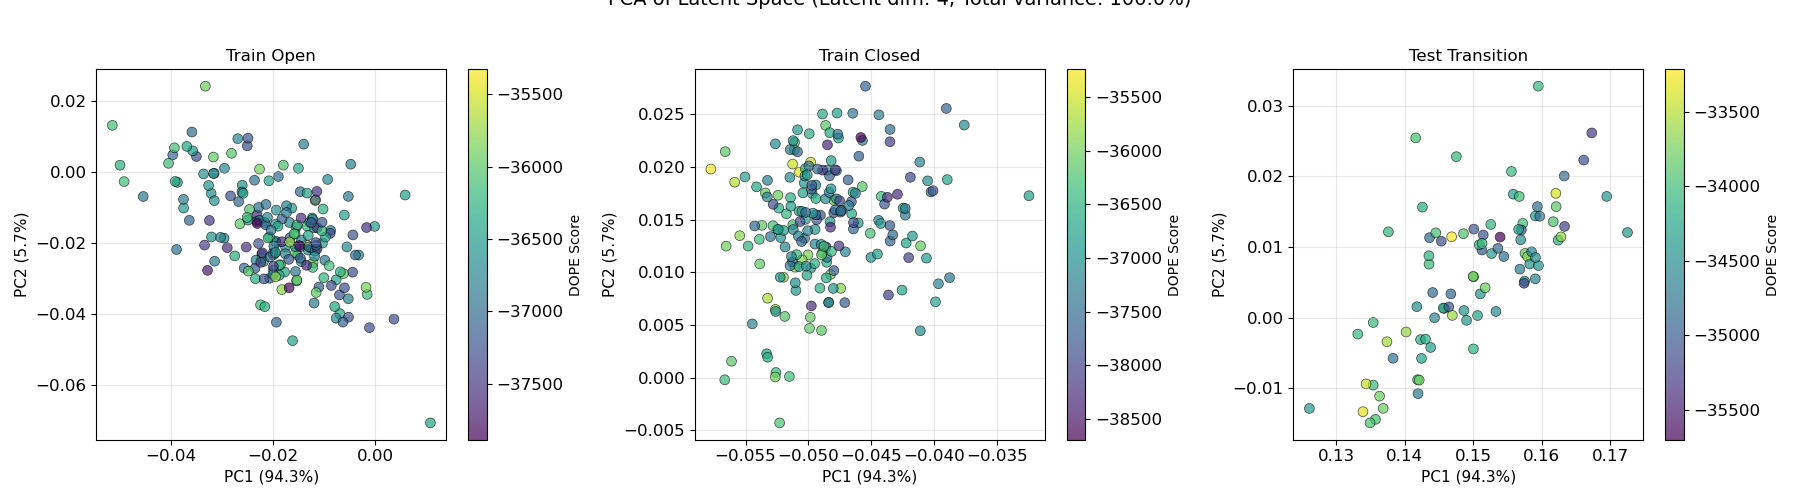

Calc Dope: 100%|██████████| 90/90 [00:04<00:00, 22.22it/s]


Latent Dim 10: Total: 100.00%


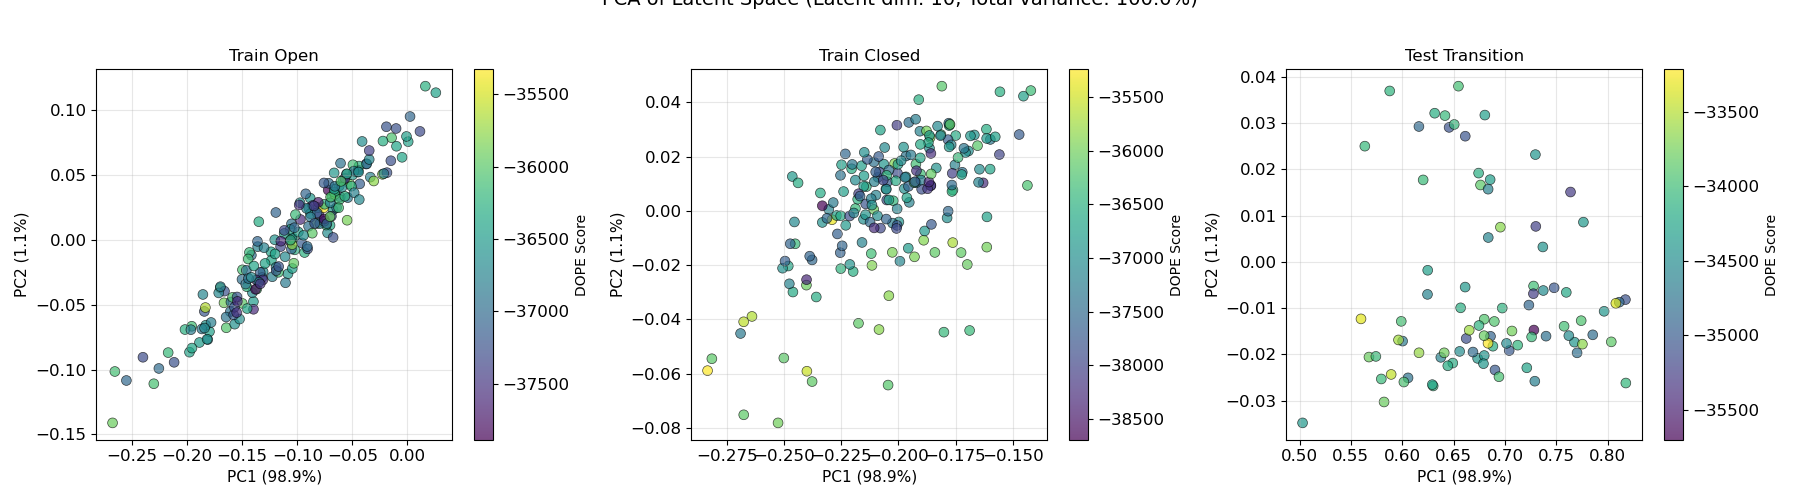

In [10]:
latent_zs = [4, 10]
refine = False
use_partial = True
step=10

dope_scores = {}
pca_results = {}
latent_original_dict = {} 

from sklearn.decomposition import PCA

pcas = {}

keys = ['train_open', 'train_closed', 'test_trans']

for latent_z in latent_zs:

    data = {}
    dope_scores[latent_z] = {}
    latent_encodings = {}

    # ============================================================
    # getting datasets, dopescores and latent encodings
    # ============================================================

    for key in keys:
        data[key] = MAs[latent_z].get_dataset(key, scale=True)[::step]
        dope_scores[latent_z][key]= MAs[latent_z].get_all_dope_score(data[key], refine=refine)
        latent_encodings[key] = MAs[latent_z].get_encoded(key)[::step]
    
    # ============================================================
    # Applying PCA
    # ============================================================

    pca = PCA(n_components=2)
    pcas[latent_z] = pca
    
    latent_all = np.vstack([latent_encodings[key] for key in keys])

    pca.fit(latent_all)

    var_pc1 = pca.explained_variance_ratio_[0] * 100
    var_pc2 = pca.explained_variance_ratio_[1] * 100
    var_total = (var_pc1 + var_pc2)
    
    print(f"Latent Dim {latent_z}: Total: {var_total:.2f}%")

    pca_results[latent_z] = {
        'train_open': pca.transform(latent_encodings['train_open']),
        'train_closed': pca.transform(latent_encodings['train_closed']),
        'test_trans': pca.transform(latent_encodings['test_trans']),
        'var_pc1': var_pc1,
        'var_pc2': var_pc2,
        'var_total': var_total,
    }
    
    # =============================================================
    # Plotting data 
    # =============================================================

    plot_data = [
        ('train_open', 'Train Open', '#FDBFCA'),
        ('train_closed', 'Train Closed', '#AFC2DC'),
        ('test_trans', 'Test Transition', '#7FB069'),
    ]
    
    plot_pca_latent_space(
        pca_results[latent_z],
        dope_scores[latent_z],
        plot_data=plot_data,
        latent_dim=latent_z,
    )

### Decoding data from this PCA space

Decoding 17x17 = 289 grid points...
Computing DOPE scores...


Calc Dope: 100%|██████████| 289/289 [00:12<00:00, 24.00it/s]


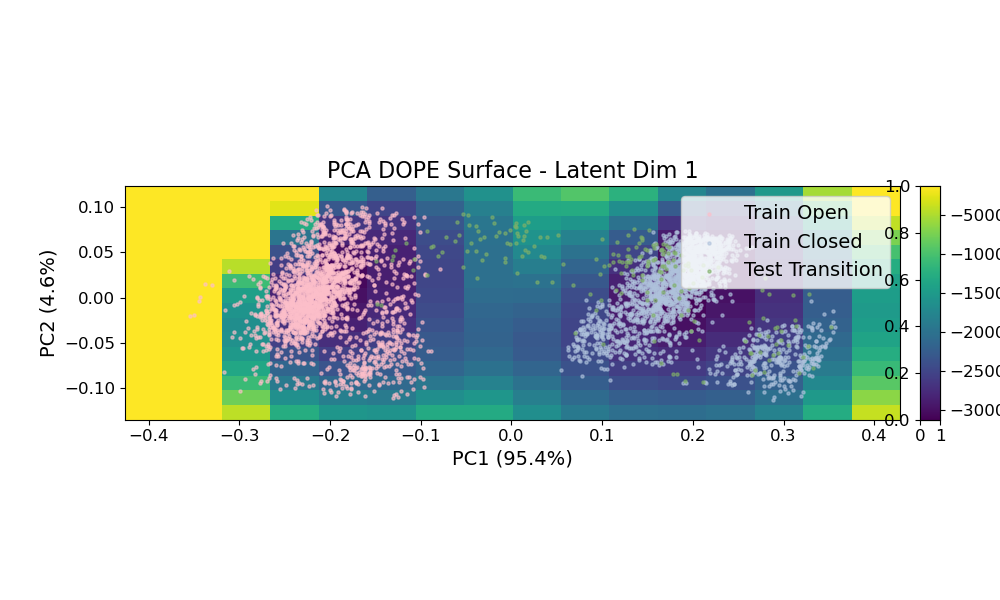

In [15]:

latent_z = 1
n_samples = 17  # Grid resolution
margin = 0.1    # 10% margin around data
refine = False

# Get all latent codes and fit PCA
latent_all = np.vstack([
    MAs[latent_z].get_encoded('train_open'),
    MAs[latent_z].get_encoded('train_closed'),
    MAs[latent_z].get_encoded('test_trans'),
])
pca = PCA(n_components=2)
pca.fit(latent_all)
pca_all = pca.transform(latent_all)

# Create grid bounds
pc1_min, pc1_max = pca_all[:, 0].min(), pca_all[:, 0].max()
pc2_min, pc2_max = pca_all[:, 1].min(), pca_all[:, 1].max()
pc1_range, pc2_range = pc1_max - pc1_min, pc2_max - pc2_min

pc1_vals = np.linspace(pc1_min - margin*pc1_range, pc1_max + margin*pc1_range, n_samples)
pc2_vals = np.linspace(pc2_min - margin*pc2_range, pc2_max + margin*pc2_range, n_samples)

# Create meshgrid in PCA space
pc1_grid, pc2_grid = np.meshgrid(pc1_vals, pc2_vals)
pca_grid_points = np.column_stack([pc1_grid.ravel(), pc2_grid.ravel()])

# Inverse transform to full latent space
latent_grid = pca.inverse_transform(pca_grid_points)

# Decode ALL points at once
print(f"Decoding {n_samples}x{n_samples} = {n_samples**2} grid points...")
with torch.no_grad():
    latent_tensor = torch.tensor(latent_grid, dtype=torch.float32)
    decoded_all = MAs[latent_z].network.decode(latent_tensor).numpy()

# Scale back to original coordinates
decoded_scaled = decoded_all * data_open.std + data_open.mean

# Compute DOPE scores for all structures at once
print("Computing DOPE scores...")
dope_grid = MAs[latent_z].get_all_dope_score(decoded_scaled, refine=refine)


dope_surface = dope_grid.reshape(n_samples, n_samples)

# Plot
def _latent_edge(values):
    return np.append(values, (2 * values[-1] - values[-2]))

surface_clip = np.percentile(dope_surface, 80)

fig, ax = plt.subplots(figsize=(10, 6))

cmap_obj = plt.cm.get_cmap('viridis')
cmap_obj.set_over(cmap_obj(1.0))

mesh = ax.pcolormesh(
    _latent_edge(pc1_vals),
    _latent_edge(pc2_vals),
    dope_surface,
    vmin=dope_surface.min(),
    vmax=surface_clip,
    cmap=cmap_obj,
    shading='auto',
)

ax.set_xlim(pc1_vals.min(), pc1_vals.max())
ax.set_ylim(pc2_vals.min(), pc2_vals.max())
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'PCA DOPE Surface - Latent Dim {latent_z}')
ax.grid(False)
ax.set_aspect('equal')

# Overlay datasets
pca_open = pca.transform(MAs[latent_z].get_encoded('train_open'))
pca_closed = pca.transform(MAs[latent_z].get_encoded('train_closed'))
pca_test = pca.transform(MAs[latent_z].get_encoded('test_trans'))

ax.scatter(pca_open[:, 0], pca_open[:, 1], c='#FDBFCA', s=5, alpha=0.6, label='Train Open')
ax.scatter(pca_closed[:, 0], pca_closed[:, 1], c='#AFC2DC', s=5, alpha=0.6, label='Train Closed')
ax.scatter(pca_test[:, 0], pca_test[:, 1], c='#7FB069', s=5, alpha=0.6, label='Test Transition')
ax.legend(loc='upper right')

cbar_ax = fig.add_axes([
    ax.get_position().x1 + 0.02,
    ax.get_position().y0,
    0.02,
    ax.get_position().height,
])

cbar_ax = fig.add_axes([
    ax.get_position().x1 + 0.02,
    ax.get_position().y0,
    0.02,
    ax.get_position().height,
])
cb = fig.colorbar(mesh, cax=cbar_ax)
cb.ax.tick_params(left=False, right=True)
cb.ax.set_ylabel('DOPE score')

plt.show()